:

In [57]:
import pandas as pd 
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
dataframe = pd.read_csv('data_HW1.csv') #Extract data set into data frame
dataframe

,0,1,2,3,4,5,6,7,8,9,...,39,40,41,42,43,44,45,46,47,48
0,-3.014000e-06,-4.413800e-05,-0.000278,-6.710100e-06,-1.504300e-05,-0.000113,0.010787,0.010831,0.011108,0.002458,...,-0.71593,1.66170,12.1770,-1.5040,-1.5041,-1.5044,-1.4984,-1.4985,-1.4984,5
1,-4.532700e-06,-2.720700e-05,0.000115,2.347100e-07,-2.236600e-05,-0.000318,0.025578,0.025605,0.025490,0.025175,...,-0.61186,2.15740,6.7002,-1.4944,-1.4944,-1.4940,-1.5048,-1.5048,-1.5049,8
2,-9.615600e-07,1.529200e-06,-0.000006,4.854600e-06,5.964500e-06,-0.000015,0.006317,0.006315,0.006321,-0.035309,...,-0.48252,6.08590,16.2140,-1.4998,-1.4998,-1.4998,-1.4975,-1.4975,-1.4975,9
3,1.856800e-06,-1.302700e-05,-0.000139,-2.323100e-06,-5.872700e-05,0.000184,0.008755,0.008768,0.008907,-0.041292,...,-0.69714,0.61270,5.6592,-1.5036,-1.5036,-1.5033,-1.4945,-1.4945,-1.4944,9
4,-1.833400e-06,6.669700e-06,0.000011,-4.316300e-06,1.245300e-06,0.000010,0.021416,0.021409,0.021399,-0.018570,...,-0.48441,4.34200,12.3630,-1.4993,-1.4993,-1.4993,-1.4978,-1.4978,-1.4978,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40951,-1.124200e-05,-4.912300e-05,0.000240,-3.430900e-06,-3.712600e-05,-0.000015,0.012029,0.012078,0.011838,0.006625,...,-0.69735,0.99880,8.7558,-1.5002,-1.5002,-1.5006,-1.4996,-1.4996,-1.4995,5
40952,2.557900e-05,-6.380400e-05,0.000317,-1.022400e-05,-3.991500e-05,-0.000116,-0.000648,-0.000584,-0.000901,0.012162,...,-0.63325,2.83800,2.7161,-1.5040,-1.5041,-1.5028,-1.4948,-1.4947,-1.4945,3
40953,-5.511600e-06,-2.435200e-05,-0.000420,2.083000e-07,-2.797300e-05,-0.000070,0.032105,0.032129,0.032549,0.013156,...,-0.86522,6.55380,11.4080,-1.5006,-1.5006,-1.5008,-1.4989,-1.4989,-1.4989,8
40954,-3.943400e-06,8.596000e-07,-0.000016,1.831200e-06,-7.038100e-07,0.000014,-0.106190,-0.106190,-0.106170,-0.199550,...,-0.47014,37.97800,41.8290,-1.4977,-1.4977,-1.4977,-1.4988,-1.4987,-1.4988,11


In [17]:
#dataframe=dataframe[:40000]
input_data = dataframe.drop(columns=['48']) #Select columns 0-47 as input
target_data = pd.DataFrame(dataframe['48']) #Select column 48 as target

train_test_split = int(len(dataframe)*0.7) #Compute train/test split index

#Split data into training and testing sets
training_inputs = input_data[:train_test_split]
training_targets = target_data[:train_test_split]

testing_inputs = input_data[train_test_split:]
testing_targets = target_data[train_test_split:]

In [22]:
def Sklearn_logistic_regression(training_inputs, training_targets,test_data):
    lr_model = LogisticRegression(max_iter=1000)
    lr_model.fit(training_inputs, training_targets.values.ravel())
    pred=lr_model.predict(test_data)
    return pred

Sklearn_logistic_regression(training_inputs,training_targets,testing_inputs)

C:\Users\Mike\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array([ 1, 10,  9, ...,  3, 11, 10], dtype=int64)

In [33]:
def train_knn(training_inputs, training_targets, test_data):
    knn_model = KNeighborsClassifier(n_neighbors=5)
    knn_model.fit(training_inputs, training_targets)
    return knn_model.predict(test_data)

C:\Users\Mike\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:198: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


array([ 9,  1,  2, ...,  6,  2, 11], dtype=int64)

In [48]:
from sklearn.ensemble import VotingClassifier
def SklearnVotingClassifier(X_train, Y_train, X_test):
    svm_classifier = SVC(probability=True)
    logreg_classifier = LogisticRegression()
    voting_classifier = VotingClassifier(
        estimators=[('svm', svm_classifier), ('logreg', logreg_classifier)],
        voting='soft'
    )
    voting_classifier.fit(X_train, Y_train)
    return voting_classifier.predict(X_test)
SklearnVotingClassifier(training_inputs,training_targets,testing_inputs)

C:\Users\Mike\anaconda3\lib\site-packages\sklearn\preprocessing\_label.py:98: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\Mike\anaconda3\lib\site-packages\sklearn\preprocessing\_label.py:133: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\Mike\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-

(array([ 1, 10,  9, ...,  3, 11, 10], dtype=int64), 0.51)

In [42]:
def Sklearn_Kmeans(input_data,k):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(input_data)
    labels = kmeans.labels_
    centroids = kmeans.cluster_centers_
    return labels, centroids
Sklearn_Kmeans(training_inputs,3)

(array([1, 1, 1, ..., 1, 1, 2]),
 array([[-2.86566116e-06,  2.33190541e-06,  3.48731969e-07,
         -1.23306908e-06,  4.64242532e-07,  7.51421309e-06,
         -1.46277992e-04, -1.48647490e-04, -1.48994595e-04,
         -2.32537062e-02, -2.32541676e-02, -2.32618680e-02,
          1.09696305e-03,  8.09376718e-04,  1.54432888e-03,
          1.09055745e-03,  5.78019846e-04,  1.45893985e-03,
          1.70187560e+00,  1.70184911e+00,  1.70170429e+00,
          1.70014892e+00,  1.70012722e+00,  1.69998251e+00,
          4.47906990e-03, -3.59573104e-02,  1.04822180e-01,
          1.70882443e-03,  1.80353421e-02,  1.57721293e-01,
         -5.16034417e-04, -5.18536309e-04, -5.14933614e-04,
         -6.92263106e-04, -6.91998576e-04, -7.01663002e-04,
         -6.51874556e-01,  5.46799884e+01,  1.38250328e+01,
         -6.38006409e-01,  1.32365532e+01,  1.17533228e+01,
         -1.49890116e+00, -1.49890232e+00, -1.49885907e+00,
         -1.49839344e+00, -1.49840077e+00, -1.49836255e+00],
      

In [9]:
def svm(training_inputs, training_targets, test_data):
    svm_model = SVC(kernel='linear')
    svm_model.fit(training_inputs, training_targets.values.ravel())
    return svm_model.predict(test_data)


print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.5558333333333333


In [3]:
def Kmeans(X_train, N, max_iters=80):
    def euclidean_distance(point1, point2):return np.sqrt(np.sum((point1 - point2) ** 2)) #Calculate distance between two points

    centroids = X_train.sample(N).to_numpy() #Initialize random centroids
    for _ in range(max_iters): #Iterate
        #Compute distances
        distances = np.array([[euclidean_distance(x, centroid) for centroid in centroids] for x in X_train.values]) 
        labels = np.argmin(distances, axis=1)  
        centroids = np.array([X_train[labels == i].mean(axis=0) for i in range(N)]) # Update centroids
    return list(centroids) #Return list of centroids
Kmeans(training_inputs,3)

[array([-3.31126189e-06,  3.52376076e-07, -7.09367402e-06, -1.00245469e-06,
         1.54396732e-06,  8.95197161e-08,  2.64821977e-03,  2.64789650e-03,
         2.65499023e-03, -9.91177700e-03, -9.91328744e-03, -9.91346734e-03,
         1.94733444e-03,  1.11904349e-03,  3.25778591e-03,  1.93833449e-03,
         1.10787421e-03,  3.23809453e-03,  1.61479412e+00,  1.61472997e+00,
         1.61422348e+00,  1.61439608e+00,  1.61433889e+00,  1.61383439e+00,
        -4.12738915e-04, -5.91058299e-03, -3.88344313e-02,  1.42459219e-03,
         1.68011365e-02, -4.12353674e-02,  2.37102725e-04,  2.36758973e-04,
         2.50123913e-04,  3.01535794e-05,  2.82069255e-05,  3.93223779e-05,
        -6.22094995e-01,  5.19033219e+00,  7.99359281e+00, -6.36031266e-01,
         4.66213630e+00,  7.73144042e+00, -1.50112401e+00, -1.50114900e+00,
        -1.50103434e+00, -1.49776193e+00, -1.49778275e+00, -1.49766274e+00]),
 array([-2.22388601e-06,  2.54499679e-06,  1.33535198e-05, -1.27068859e-06,
         7

In [15]:

print("Predicted Label:", result)
print("Unique Neighbor Labels:", unique_values)
print("Counts of Unique Neighbor Labels:", counts)
print(kn)

Predicted Label: 7
Unique Neighbor Labels: [ 1  2  3  4  5  6  7  8  9 10 11]
Counts of Unique Neighbor Labels: [20 40 40 20 70 50 80 40 40 60 20]
[[[ 5]
  [ 9]
  [ 6]
  [ 8]
  [ 6]
  [ 9]
  [10]
  [ 3]
  [ 5]
  [ 5]
  [10]
  [ 8]
  [ 9]
  [ 5]
  [ 2]
  [ 6]
  [10]
  [ 3]
  [ 7]
  [ 5]
  [ 8]
  [10]
  [ 7]
  [ 7]
  [ 4]
  [ 7]
  [ 2]
  [ 5]
  [ 3]
  [ 2]
  [ 9]
  [ 4]
  [ 3]
  [10]
  [ 7]
  [11]
  [ 6]
  [ 7]
  [ 1]
  [ 1]
  [ 7]
  [ 6]
  [ 7]
  [11]
  [10]
  [ 2]
  [ 8]
  [ 5]]

 [[ 9]
  [ 5]
  [ 6]
  [ 8]
  [ 9]
  [ 6]
  [10]
  [ 8]
  [ 2]
  [ 6]
  [ 7]
  [ 3]
  [ 2]
  [ 9]
  [ 4]
  [10]
  [ 3]
  [ 7]
  [10]
  [ 3]
  [ 5]
  [ 5]
  [ 5]
  [ 5]
  [ 9]
  [ 7]
  [ 7]
  [ 2]
  [10]
  [ 8]
  [ 5]
  [ 3]
  [ 7]
  [11]
  [10]
  [11]
  [ 1]
  [ 6]
  [ 7]
  [ 6]
  [ 7]
  [ 1]
  [ 4]
  [ 7]
  [ 2]
  [10]
  [ 8]
  [ 5]]

 [[ 2]
  [ 5]
  [ 9]
  [ 8]
  [ 9]
  [ 6]
  [ 6]
  [ 8]
  [ 6]
  [10]
  [ 7]
  [ 4]
  [ 7]
  [ 7]
  [ 2]
  [ 5]
  [ 3]
  [10]
  [ 3]
  [ 2]
  [ 9]
  [ 3]
  [10]
  [ 7]
  [ 3]
  

In [ ]:
def KNN(train_data, train_labels, test_data, k=5):
    predictions = []
    for test_point in test_data.values:
        distances = np.array([np.sqrt(np.sum((test_point - train_point) ** 2)) for train_point in train_data.values])
        # Get the indices of the k-nearest neighbors
        nearest_indices = np.argsort(distances)[:k]
        # Get the labels of the k-nearest neighbors
        nearest_labels = train_labels.iloc[nearest_indices]
        # Predict the class with the majority vote
        prediction = nearest_labels.mode().iloc[0]
        predictions.append(prediction)
    return predictions

C:\Users\Mike\anaconda3\lib\site-packages\sklearn\utils\validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


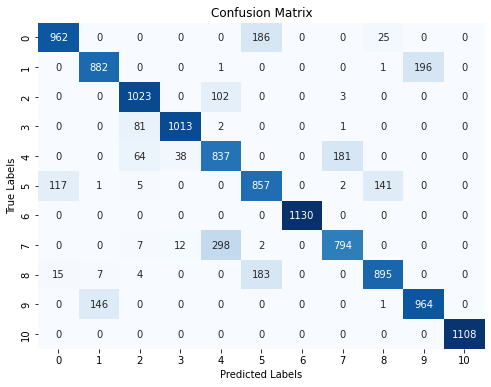

In [49]:
"""
Predicitve_Analytics.py
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
def Accuracy(y_true,y_pred):
    """
    :type y_true: numpy.ndarray
    :type y_pred: numpy.ndarray
    :rtype: float
    
    """

def Recall(y_true,y_pred):
     """
    :type y_true: numpy.ndarray
    :type y_pred: numpy.ndarray
    :rtype: float
    """

def Precision(y_true,y_pred):
    """
    :type y_true: numpy.ndarray
    :type y_pred: numpy.ndarray
    :rtype: float
    """
def WCSS(Clusters):
    """
    :Clusters List[numpy.ndarray]
    :rtype: float
    """
def ConfusionMatrix(y_true,y_pred):
    
    """
    :type y_true: numpy.ndarray
    :type y_pred: numpy.ndarray
    :rtype: float
    """  

def KNN(train_data, train_labels, test_data, k=5):
    predictions = [] #Initialize list of predictions
    for test_point in test_data.values: #Iterate through test points
        distances = np.array([np.sqrt(np.sum((test_point - train_point) ** 2)) for train_point in train_data.values]) #Compute euclidean distances
        k_indices = np.argsort(distances)[:k] #Gather nearest neighbor indices
        k_labels = train_labels.iloc[k_indices] #Gather labels of nearest neighbors
        prediction = k_labels.mode().iloc[0] #Compute most frequent element of k nearest neighbors
        predictions.append(prediction) #Add prediction to list of predictions
    return np.array([predictions]) #Return array of predictions

    
def Kmeans(X_train, N, max_iters=80):
    def euclidean_distance(point1, point2):return np.sqrt(np.sum((point1 - point2) ** 2)) #Calculate distance between two points
    centroids = X_train.sample(N).to_numpy() #Initialize random centroids
    for _ in range(max_iters): #Iterate
        #Compute distances
        distances = np.array([[euclidean_distance(x, centroid) for centroid in centroids] for x in X_train.values]) 
        labels = np.argmin(distances, axis=1)  
        centroids = np.array([X_train[labels == i].mean(axis=0) for i in range(N)]) # Update centroids
    return list(centroids) #Return list of centroids


def Sklearn_SVM(training_inputs, training_targets, test_data):
    svm_model = SVC(kernel='linear')
    svm_model.fit(training_inputs, training_targets.values.ravel())
    return svm_model.predict(test_data)

def Sklearn_logistic_regression(training_inputs, training_targets,test_data):
    lr_model = LogisticRegression(max_iter=1000)
    lr_model.fit(training_inputs, training_targets.values.ravel())
    return lr_model.predict(test_data)

def Sklearn_Kmeans(input_data,k):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(input_data)
    labels = kmeans.labels_
    centroids = kmeans.cluster_centers_
    return labels, centroids

def Sklearn_KNN(training_inputs, training_targets, test_data,k=7):
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(training_inputs, training_targets)
    return knn_model.predict(test_data)

def SklearnVotingClassifier(X_train,Y_train,X_test):
    svm_classifier = SVC(probability=True)
    logreg_classifier = LogisticRegression()
    voting_classifier = VotingClassifier(
        estimators=[('svm', svm_classifier), ('logreg', logreg_classifier)],
        voting='soft'
    )
    voting_classifier.fit(X_train, Y_train)
    return voting_classifier.predict(X_test)


"""
Create your own custom functions for Matplotlib visualization of hyperparameter search. 
Make sure that plots are labeled and proper legends are used
"""


dataframe = pd.read_csv('data_HW1.csv') #Extract data set into data frame

input_data = dataframe.drop(columns=['48']) #Select columns 0-47 as input
target_data = pd.DataFrame(dataframe['48']) #Select column 48 as target

train_test_split = int(len(dataframe)*0.7) #Compute train/test split index

#Split data into training and testing sets
training_inputs = input_data[:train_test_split]
training_targets = target_data[:train_test_split]

testing_inputs = input_data[train_test_split:]
testing_targets = target_data[train_test_split:]

svm_model = SVC(kernel='linear')
svm_model.fit(training_inputs, training_targets)

# Make predictions on the testing data
y_pred = svm_model.predict(testing_inputs)

# Compute the confusion matrix
confusion = confusion_matrix(testing_targets, y_pred)

# Create a visualization of the confusion matrix

plt.figure(figsize=(8, 6))
sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

C:\Users\Mike\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:198: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\Mike\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:198: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\Mike\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:198: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\Mike\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:198: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples

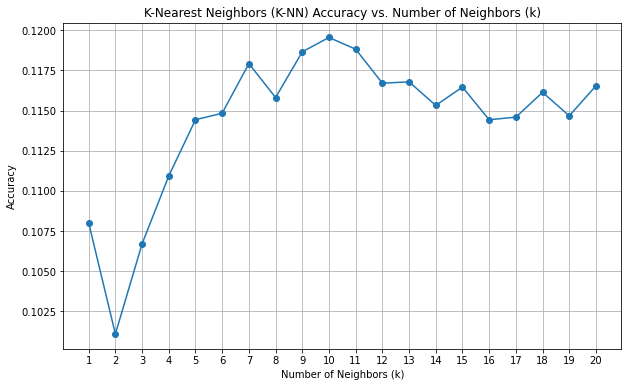

In [56]:
# Initialize lists to store accuracy values for different k values
k_values = list(range(1, 21))  # Adjust the range as needed
accuracy_scores = []

# Iterate through different k values and compute accuracy
for k in k_values:
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(training_inputs, training_targets)
    y_pred = knn_model.predict(testing_inputs)
    accuracy = accuracy_score(testing_targets, y_pred)
    accuracy_scores.append(accuracy)

# Create a plot to visualize accuracy vs. k values
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracy_scores, marker='o', linestyle='-')
plt.title('K-Nearest Neighbors (K-NN) Accuracy vs. Number of Neighbors (k)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.grid(True)
plt.show()